In [1]:
import pandas as pd
df = pd.read_csv("train.csv")

print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [2]:
df.info()
df.describe()
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [3]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [4]:
print(df.duplicated().sum())

0


In [5]:
import matplotlib.pyplot as plt
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print(corr.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


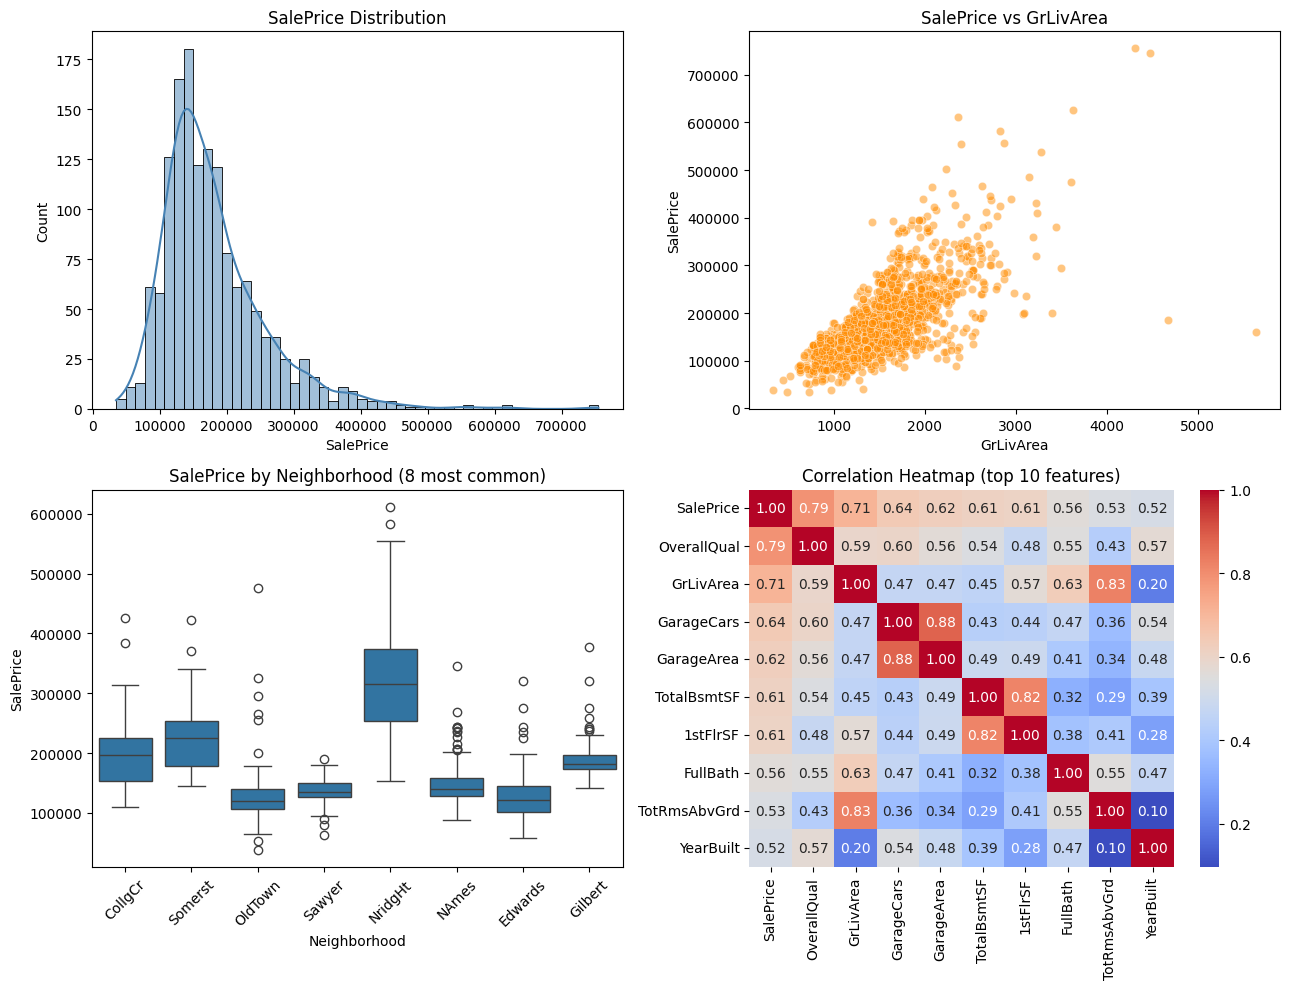

In [6]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.histplot(df["SalePrice"], bins=50, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("SalePrice Distribution")

sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", alpha=0.5, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("SalePrice vs GrLivArea")

top_neighborhoods = df["Neighborhood"].value_counts().head(8).index
sns.boxplot(data=df[df["Neighborhood"].isin(top_neighborhoods)],
            x="Neighborhood", y="SalePrice", ax=axes[1, 0])
axes[1, 0].set_title("SalePrice by Neighborhood (8 most common)")
axes[1, 0].tick_params(axis="x", rotation=45)

top_corr_features = corr.abs().sort_values(ascending=False).head(10).index
sns.heatmap(df[top_corr_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap (top 10 features)")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

def iqr_cap(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

outlier_prone_cols = [
    "SalePrice", "GrLivArea", "LotArea", "LotFrontage", "TotalBsmtSF",
    "1stFlrSF", "2ndFlrSF", "GarageArea", "MasVnrArea",
    "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "MiscVal",
]

changed_counts = {}
for col in outlier_prone_cols:
    before = df[col].copy()
    df[col] = iqr_cap(df[col])
    changed_counts[col] = int((before != df[col]).sum())

print("Values capped per column:")
for c, n in changed_counts.items():
    print(f"  {c}: {n}")

Values capped per column:
  SalePrice: 61
  GrLivArea: 31
  LotArea: 69
  LotFrontage: 347
  TotalBsmtSF: 61
  1stFlrSF: 20
  2ndFlrSF: 2
  GarageArea: 21
  MasVnrArea: 104
  WoodDeckSF: 32
  OpenPorchSF: 77
  EnclosedPorch: 208
  MiscVal: 52


In [8]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["TotalBath"] = (df["FullBath"] + 0.5 * df["HalfBath"]
                    + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"])

In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

categ_cols = df.select_dtypes(include=['object']).columns

/tmp/ipykernel_545/444730763.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categ_cols = df.select_dtypes(include=['object']).columns


In [10]:
df = pd.get_dummies(df, columns=categ_cols, drop_first=True)

In [11]:
# Drop Id: it's a row identifier, not a predictive feature
x = df.drop(["SalePrice", "Id"], axis=1)
y = df["SalePrice"]

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

dt_param_grid = {
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
dt_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
dt_search.fit(x_train, y_train)
print("Decision Tree best parameters:", dt_search.best_params_)
dt_tuned = dt_search.best_estimator_

Decision Tree best parameters: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
}
rf_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
rf_search.fit(x_train, y_train)
print("Random Forest best parameters:", rf_search.best_params_)
rf_tuned = rf_search.best_estimator_

Random Forest best parameters: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 100}


In [16]:
from xgboost import XGBRegressor

xgb_param_grid = {
  'n_estimators': [100, 200, 300],
  'max_depth': [3, 4, 5],
}
xgb_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
xgb_search.fit(x_train, y_train)
print("XGBoost best parameters:", xgb_search.best_params_)
xgb_tuned = xgb_search.best_estimator_

XGBoost best parameters: {'max_depth': 4, 'n_estimators': 100}


In [17]:
from sklearn.model_selection import cross_val_score

models_for_cv = {
    "Linear Regression": lr,
    "Decision Tree (tuned)": dt_tuned,
    "Random Forest (tuned)": rf_tuned,
    "XGBoost (tuned)": xgb_tuned,
}

cv_results = {}
for name, model in models_for_cv.items():
    scores = -cross_val_score(model, x_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    cv_results[name] = (scores.mean(), scores.std())
    print(f"{name}: CV RMSE = {scores.mean():,.0f} (+/- {scores.std():,.0f})")

Linear Regression: CV RMSE = 21,704 (+/- 3,666)


Decision Tree (tuned): CV RMSE = 30,287 (+/- 3,080)


Random Forest (tuned): CV RMSE = 21,927 (+/- 3,459)


XGBoost (tuned): CV RMSE = 20,817 (+/- 2,220)


In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pred_lr = lr.predict(x_test)
mse_lr = mean_squared_error(y_test, pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pred_lr)
print("Linear Regression - RMSE: ", rmse_lr)
print("Linear Regression - R2 Score: ", r2_lr)
print("mse: ", mse_lr)

Linear Regression - RMSE:  22401.708683553603
Linear Regression - R2 Score:  0.8973591951463682
mse:  501836551.94280094


In [19]:
pred_dt = dt_tuned.predict(x_test)
mse_dt = mean_squared_error(y_test, pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, pred_dt)

pred_rf = rf_tuned.predict(x_test)
mse_rf = mean_squared_error(y_test, pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, pred_rf)

pred_xgb_tuned = xgb_tuned.predict(x_test)
mse_xgb_tuned = mean_squared_error(y_test, pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, pred_xgb_tuned)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree (tuned)", "Random Forest (tuned)", "XGBoost (tuned)"],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_xgb_tuned],
    "R2 Score": [r2_lr, r2_dt, r2_rf, r2_xgb_tuned],
}).sort_values("RMSE").reset_index(drop=True)

print(results)

                   Model          RMSE  R2 Score
0        XGBoost (tuned)  20526.453546  0.913824
1  Random Forest (tuned)  20717.703756  0.912211
2      Linear Regression  22401.708684  0.897359
3  Decision Tree (tuned)  27888.359718  0.840924
